# Latent Dirichlet Allocation

## Preparing Data to Apply LDA topic modelling

In [37]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [57]:
import os
import pandas as pd

df_wvs = pd.read_csv('../data/processed/1_dataprep/wvs_filtered_waves4to7.csv')

## Function to Encode and Impute Survey Answers

In [58]:

### Run at the beginning, to get and wsv_encoded

def recode_survey_responses(df_wvs, question_columns, neutral_values={3, 5}):
    """
    Following Draca & Schwarz (2024) methodology, this function recodes responses from WVS waves 4-7 
    into support and oppose indicators (binary variables), and imputes missing values.

    Parameters:
    - df_wvs (pd.DataFrame): Survey DataFrame already clean and filtered for waves 4-7
    - question_columns (list): List of variables (column names) to be recoded. In this case, stored in a separate json file.
    - neutral_values (set): Values representing neutrality (not used here but can be extended).
    
    Returns:
    - pd.DataFrame: Transformed DataFrame with support/oppose indicators and country, year, wave, sex", age (intervals of 8), and education level.
    """

    # Impute missing values for each question column
    for col in question_columns:
        valid_values = df_wvs[df_wvs[col] >= 0][col]
        mean_value = valid_values.mean()
        df_wvs[col] = df_wvs[col].apply(lambda x: mean_value if x < 0 else x) #All negative values are replaced with the mean of the column

    # Recode into support and oppose
    ### This has to be adjusted to the specific questions logic and their scales
    for col in question_columns:
        if col == "C002":  # 1–3 scale (agree-disagree)
            df_wvs[f"{col}_support"] = df_wvs[col].apply(lambda x: 1 if x == 1 else 0)
            df_wvs[f"{col}_oppose"] = df_wvs[col].apply(lambda x: 1 if x == 2 else 0)
        elif col in ["G006", "E069_01", "E069_02", "E069_04", "E069_05", "E069_06",
             "E069_07", "E069_08", "E069_13", "E069_17"]:  # 1–4 scale
             df_wvs[f"{col}_support"] = df_wvs[col].apply(lambda x: 1 if x in [1, 2] else 0)
             df_wvs[f"{col}_oppose"] = df_wvs[col].apply(lambda x: 1 if x in [3, 4] else 0)
        elif col in ["E036", "E037", "E039"] or "F1" in col:  # 1–10 scale
            df_wvs[f"{col}_support"] = df_wvs[col].apply(lambda x: 1 if x >= 6 else 0)
            df_wvs[f"{col}_oppose"] = df_wvs[col].apply(lambda x: 1 if x <= 4 else 0)
        else:  # Binary 0–1
            df_wvs[f"{col}_support"] = df_wvs[col]
            df_wvs[f"{col}_oppose"] = 1 - df_wvs[col]

    # Keep only relevant columns
    interest_columns = ["country", "year", "wave", "sex", "age_6", "education_l"] + \
                       [f"{col}_support" for col in question_columns] + \
                       [f"{col}_oppose" for col in question_columns]

    return df_wvs[interest_columns]



## Defining Variables to Apply the Function for Encoding and Imputation

In [59]:
import json

# Previously saved in the dictionary from the variable_dict.json file
with open("variable_dict.json", "r", encoding="utf-8") as file:
    variable_dict = json.load(file)

# Get the list of question columns (i.e., just the keys)
question_columns = list(variable_dict.keys())

## Applying the Function

In [60]:
df_encoded = recode_survey_responses(df_wvs, question_columns)

In [61]:
# Checking the columns of the transformed DataFrame
print(df_encoded.columns)

# Defining folder to save encoded data 2_lda folder
output_dir = '../data/processed/2_lda_encoded'

# Save full encoded dataset
df_encoded.to_csv(os.path.join(output_dir, 'wvs_encoded.csv'), index=False)

Index(['country', 'year', 'wave', 'sex', 'age_6', 'education_l',
       'A124_02_support', 'A124_06_support', 'A124_07_support',
       'A124_08_support', 'A124_09_support', 'C002_support', 'E036_support',
       'E037_support', 'E039_support', 'F114A_support', 'F115_support',
       'F116_support', 'F117_support', 'F118_support', 'F119_support',
       'F120_support', 'F121_support', 'F122_support', 'F123_support',
       'G006_support', 'E069_01_support', 'E069_02_support', 'E069_04_support',
       'E069_05_support', 'E069_06_support', 'E069_07_support',
       'E069_08_support', 'E069_13_support', 'E069_17_support',
       'A124_02_oppose', 'A124_06_oppose', 'A124_07_oppose', 'A124_08_oppose',
       'A124_09_oppose', 'C002_oppose', 'E036_oppose', 'E037_oppose',
       'E039_oppose', 'F114A_oppose', 'F115_oppose', 'F116_oppose',
       'F117_oppose', 'F118_oppose', 'F119_oppose', 'F120_oppose',
       'F121_oppose', 'F122_oppose', 'F123_oppose', 'G006_oppose',
       'E069_01_oppos

## Splitting and Saving the Re-Coded Data for Each Wave

In [62]:
output_dir = '../data/processed/2_lda_encoded'
os.makedirs(output_dir, exist_ok=True)  # Make sure the directory exists

# Load encoded dataset
df_encoded = pd.read_csv(os.path.join(output_dir, 'wvs_encoded.csv'))

# Dictionary to store each wave DataFrame
wave_dfs = {}

# Filter and save each wave using the wave column directly
for wave in [4, 5, 6, 7]:
    df_wave = df_encoded[df_encoded["wave"] == wave].copy()
    df_wave.to_csv(os.path.join(output_dir, f'wvs_wave{wave}.csv'), index=False)
    wave_dfs[wave] = df_wave  # Save each wave df in dictionary

# Check the dimensions of all the frames (wave 4-7)
for wave, df in wave_dfs.items():
    print(f"Wave {wave} dimensions: {df.shape}")

# Column names of the transformed DataFrames
print("\nColumn names of the transformed DataFrames:")
for wave, df in wave_dfs.items():
    print(f"Wave {wave} columns: {df.columns.tolist()}")

Wave 4 dimensions: (45146, 64)
Wave 5 dimensions: (58936, 64)
Wave 6 dimensions: (60783, 64)
Wave 7 dimensions: (64398, 64)

Column names of the transformed DataFrames:
Wave 4 columns: ['country', 'year', 'wave', 'sex', 'age_6', 'education_l', 'A124_02_support', 'A124_06_support', 'A124_07_support', 'A124_08_support', 'A124_09_support', 'C002_support', 'E036_support', 'E037_support', 'E039_support', 'F114A_support', 'F115_support', 'F116_support', 'F117_support', 'F118_support', 'F119_support', 'F120_support', 'F121_support', 'F122_support', 'F123_support', 'G006_support', 'E069_01_support', 'E069_02_support', 'E069_04_support', 'E069_05_support', 'E069_06_support', 'E069_07_support', 'E069_08_support', 'E069_13_support', 'E069_17_support', 'A124_02_oppose', 'A124_06_oppose', 'A124_07_oppose', 'A124_08_oppose', 'A124_09_oppose', 'C002_oppose', 'E036_oppose', 'E037_oppose', 'E039_oppose', 'F114A_oppose', 'F115_oppose', 'F116_oppose', 'F117_oppose', 'F118_oppose', 'F119_oppose', 'F120_op

# LDA Application

## Finding Optimal Number of Ideology Types per Wave

Defining the functions to obtain Normalized Pointwise Mutual Information (NPMI) scores, a metric that measures the semantic coherence of topics.

In [63]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
import os
import joblib
from itertools import combinations

####### Setup
num_folds = 10
topic_range = range(1, 11)  # K = 1 to 10
data_folder = "data"
results_folder = "../data/reports/model_evaluation"
os.makedirs(results_folder, exist_ok=True)


##### NPMI Function
def compute_npmi(issue_list, test_data):
    """Calculates the average NPMI for a group of variables (issues), which reflects
      how often the top variables in a topic co-occur in the data. The more frequently
      they co-occur, the more coherent the topic is."""
    N = len(test_data)
    epsilon = 1e-10

    binary_data = test_data[issue_list].astype(int)
    issue_counts = binary_data.sum(axis=0).to_dict()

    npmi_scores = []
    for i, j in combinations(issue_list, 2):
        p_i = issue_counts[i] / N
        p_j = issue_counts[j] / N
        p_ij = ((binary_data[i] & binary_data[j]).sum()) / N

        if p_ij > 0:
            pmi = np.log(p_ij / (p_i * p_j + epsilon))
            npmi = pmi / (-np.log(p_ij + epsilon))
            npmi_scores.append(npmi)

    return np.mean(npmi_scores) if npmi_scores else 0



##### Evaluation Function (using the compute_npmi function)
def evaluate_model_with_npmi(model, test_data, train_data):
    """ Applies the compute_npmi() function to all topics in a trained LDA model to get an overall coherence score."""
    feature_names = train_data.columns
    topic_words = pd.DataFrame(model.components_, columns=feature_names)
    top_issues_per_topic = topic_words.apply(lambda x: x.nlargest(5).index.tolist(), axis=1)

    topic_npmis = [compute_npmi(issue_list, test_data) for issue_list in top_issues_per_topic]
    return np.mean(topic_npmis)

# Evaluating LDA Models Using NPMI for Topic Optimization Across Waves

In [64]:
def process_wave_from_df(wave_number, df_wave):
    print(f"\n🌊 Processing Wave {wave_number}")

    # Drop metadata columns so that LDA only uses issue variables
    lda_data = df_wave.drop(columns=["country", "year", "wave", "sex", "age_6", "education_l"])

    # Initialize K-Fold cross-validator
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=30)

    # To store NPMI evaluation scores across folds and topic numbers
    evaluation_matrix = np.zeros((num_folds, len(topic_range)))
    npmi_scores_per_topic = {k: [] for k in topic_range}

    # Cross-validation loop
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(lda_data)):
        print(f"📂 Fold {fold_idx + 1}/{num_folds}")

        train_data = lda_data.iloc[train_idx]
        test_data = lda_data.iloc[test_idx]

        for k_idx, n_topics in enumerate(topic_range):
            lda = LatentDirichletAllocation(
                n_components=n_topics,
                doc_topic_prior=0.25,
                topic_word_prior=0.1,
                learning_method='online',
                learning_decay=0.7,
                learning_offset=10.0,
                max_iter=20,
                batch_size=1000,
                evaluate_every=-1,
                mean_change_tol=0.001,
                max_doc_update_iter=100,
                n_jobs=-1,  # Uses all cores for this model
                random_state=30
            )
            lda.fit(train_data)

            # Evaluate using NPMI with held-out test data
            npmi_score = evaluate_model_with_npmi(lda, test_data, train_data)
            evaluation_matrix[fold_idx, k_idx] = npmi_score
            npmi_scores_per_topic[n_topics].append(npmi_score)

    # Compute the average NPMI across all folds for each topic count
    avg_npmis = {k: np.mean(npmi_scores_per_topic[k]) for k in topic_range}

    # Identify the optimal number of topics
    optimal_k = max(avg_npmis, key=avg_npmis.get)
    print(f"🏆 Optimal number of topics for Wave {wave_number}: K={optimal_k}")

    # Save evaluation results
    eval_df = pd.DataFrame(evaluation_matrix, columns=[f"K={k}" for k in topic_range])
    eval_df.to_csv(f"../data/reports/model_evaluation/wave{wave_number}_evaluation.csv", index=False)
    print(f"✅ Saved evaluation results for Wave {wave_number}")


# Run for waves 4–7 sequentially to avoid CPU overload
for wave_number, df in wave_dfs.items():  # Directly use wave_dfs dictionary
    process_wave_from_df(wave_number, df)

print("\n🎯 Done! All waves processed using NPMI evaluation.")


🌊 Processing Wave 4
📂 Fold 1/10
📂 Fold 2/10
📂 Fold 3/10
📂 Fold 4/10
📂 Fold 5/10
📂 Fold 6/10
📂 Fold 7/10
📂 Fold 8/10
📂 Fold 9/10
📂 Fold 10/10
🏆 Optimal number of topics for Wave 4: K=5
✅ Saved evaluation results for Wave 4

🌊 Processing Wave 5
📂 Fold 1/10
📂 Fold 2/10
📂 Fold 3/10
📂 Fold 4/10
📂 Fold 5/10
📂 Fold 6/10
📂 Fold 7/10
📂 Fold 8/10
📂 Fold 9/10
📂 Fold 10/10
🏆 Optimal number of topics for Wave 5: K=5
✅ Saved evaluation results for Wave 5

🌊 Processing Wave 6
📂 Fold 1/10
📂 Fold 2/10
📂 Fold 3/10
📂 Fold 4/10
📂 Fold 5/10
📂 Fold 6/10
📂 Fold 7/10
📂 Fold 8/10
📂 Fold 9/10
📂 Fold 10/10
🏆 Optimal number of topics for Wave 6: K=5
✅ Saved evaluation results for Wave 6

🌊 Processing Wave 7
📂 Fold 1/10
📂 Fold 2/10
📂 Fold 3/10
📂 Fold 4/10
📂 Fold 5/10
📂 Fold 6/10
📂 Fold 7/10
📂 Fold 8/10
📂 Fold 9/10
📂 Fold 10/10
🏆 Optimal number of topics for Wave 7: K=7
✅ Saved evaluation results for Wave 7

🎯 Done! All waves processed using NPMI evaluation.


# Visualise the NPMI evaluation scores per wave

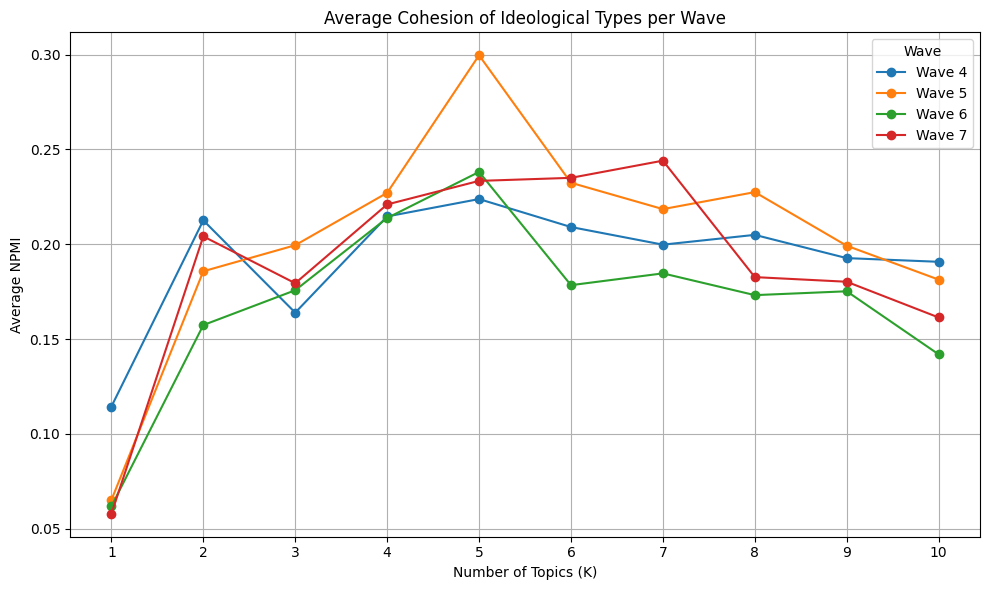

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import os

results_folder = "../data/reports/model_evaluation"
waves = [4, 5, 6, 7]
npmi_data = {}

for wave in waves:
    path = os.path.join(results_folder, f"wave{wave}_evaluation.csv")
    df = pd.read_csv(path)
    
    # Each column is a K, each row is a fold — average across rows (folds)
    mean_npmi = df.mean(axis=0)
    
    # Create a DataFrame with 'K' and 'waveX' columns
    temp_df = pd.DataFrame({
        "K": [int(k.split('=')[1]) if isinstance(k, str) and "=" in k else int(k) for k in mean_npmi.index],
        f"wave{wave}": mean_npmi.values
    }).set_index("K")
    
    npmi_data[wave] = temp_df

# Combine all waves into one DataFrame
combined_df = pd.concat(npmi_data.values(), axis=1)

# Plot
plt.figure(figsize=(10, 6))
for wave in waves:
    plt.plot(combined_df.index, combined_df[f"wave{wave}"], marker='o', label=f"Wave {wave}")

plt.title("Average Cohesion of Ideological Types per Wave")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Average NPMI")
plt.legend(title="Wave")
plt.grid(True)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()